# 📊 Analyse de Sentiment - Avis Trustpilot

## Objectif du Notebook
Ce notebook présente une **analyse de sentiment basique** sur les avis clients Trustpilot scrapés.

**Données disponibles :**
- 21,795 avis clients
- 52 entreprises
- Champs : `content`, `title`, `rating` (1-5 étoiles)

**Approche ML :**
1. Exploration des données
2. Prétraitement du texte
3. Vectorisation (TF-IDF)
4. Classification avec plusieurs modèles
5. Évaluation et prédiction

## 1️⃣ Import des bibliothèques nécessaires

Nous importons toutes les bibliothèques requises pour l'analyse de sentiment.

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Connexion Elasticsearch
from elasticsearch import Elasticsearch

# Traitement du langage naturel
import re
from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    roc_curve, 
    auc
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configuration
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Toutes les bibliothèques sont importées avec succès!")

✓ Toutes les bibliothèques sont importées avec succès!


## 2️⃣ Chargement des données depuis Elasticsearch

Connexion à Elasticsearch et récupération des **21,795 avis** Trustpilot.

In [2]:
# Connexion à Elasticsearch - Fix compatibilité version
from elasticsearch import Elasticsearch

# Créer le client avec forçage de compatibilité version 7
es = Elasticsearch(
    hosts=[{'host': 'localhost', 'port': 9200, 'scheme': 'http'}],
    request_timeout=30,
    max_retries=3,
    retry_on_timeout=True
)

# Vérifier la connexion
try:
    if es.ping():
        print("✓ Connexion à Elasticsearch réussie")
        # Afficher la version
        info = es.info()
        print(f"  Version Elasticsearch: {info['version']['number']}")
    else:
        print("✗ Erreur de connexion à Elasticsearch")
        print("  Assurez-vous que Docker est démarré: docker-compose up -d")
except Exception as e:
    print(f"✗ Erreur de connexion: {e}")
    print("  Lancez Docker avec: docker-compose up -d")

# Récupérer tous les avis (scroll API pour gros volumes)
def load_reviews_from_elasticsearch(index_name='trustpilot_reviews', batch_size=1000):
    """
    Charge tous les avis depuis Elasticsearch
    """
    reviews = []
    
    try:
        # Première requête avec scroll - syntaxe compatible v7/v8
        response = es.search(
            index=index_name,
            scroll='2m',
            size=batch_size,
            body={"query": {"match_all": {}}}
        )
        
        scroll_id = response['_scroll_id']
        hits = response['hits']['hits']
        reviews.extend(hits)
        
        print(f"  Premier batch: {len(hits)} avis")
        
        # Continuer à récupérer les résultats
        batch_num = 1
        while len(hits) > 0:
            response = es.scroll(scroll_id=scroll_id, scroll='2m')
            scroll_id = response['_scroll_id']
            hits = response['hits']['hits']
            reviews.extend(hits)
            
            if len(hits) > 0:
                batch_num += 1
                if batch_num % 10 == 0:  # Afficher tous les 10 batches
                    print(f"  Batch {batch_num}: {len(reviews)} avis chargés...")
        
        return reviews
    
    except Exception as e:
        print(f"Erreur lors du chargement: {e}")
        print(f"Type d'erreur: {type(e).__name__}")
        return []

# Charger les données
print("\nChargement des avis depuis Elasticsearch...")
raw_reviews = load_reviews_from_elasticsearch()
print(f"\n✓ {len(raw_reviews)} avis chargés au total")

# Convertir en DataFrame
if len(raw_reviews) > 0:
    df = pd.DataFrame([hit['_source'] for hit in raw_reviews])
    print(f"\n📊 Shape du dataset: {df.shape}")
    print(f"   Colonnes: {list(df.columns)}")
else:
    print("\n⚠️ Aucune donnée chargée!")
    print("   Solutions:")
    print("   1. Vérifiez que Docker est démarré: docker ps")
    print("   2. Démarrez les services: docker-compose up -d")
    print("   3. Attendez 30s que Elasticsearch soit prêt")
    print("   4. Relancez cette cellule")

✓ Connexion à Elasticsearch réussie
  Version Elasticsearch: 8.11.0

Chargement des avis depuis Elasticsearch...
  Premier batch: 1000 avis  Premier batch: 1000 avis

  Batch 10: 10000 avis chargés...
  Batch 10: 10000 avis chargés...
  Batch 20: 20000 avis chargés...

✓ 21795 avis chargés au total
  Batch 20: 20000 avis chargés...

✓ 21795 avis chargés au total

📊 Shape du dataset: (21795, 30)
   Colonnes: ['review_id', 'review_url', 'stars', 'rating', 'score', 'title', 'content', 'comment_text', 'date_absolute', 'date', 'date_relative', 'date_text', 'author_name', 'reviewer_name', 'author_location', 'author_review_count', 'reviewer_total_reviews', 'has_company_reply', 'company_replied', 'company_reply', 'company_reply_text', 'company_reply_date_absolute', 'company_reply_date', 'company_reply_date_relative', 'is_verified', 'experience_date_text', 'helpful_count', 'scraped_at', 'company_name', 'company_url']

📊 Shape du dataset: (21795, 30)
   Colonnes: ['review_id', 'review_url', 'sta

## 3️⃣ Exploration des données

Analysons la structure et la distribution de nos données.

In [3]:
# Afficher les premières lignes
print("=== Aperçu des données ===")
print(df.head())

print("\n=== Informations sur le dataset ===")
print(df.info())

print("\n=== Colonnes disponibles ===")
print(df.columns.tolist())

print("\n=== Statistiques descriptives ===")
print(df.describe())

# Vérifier les valeurs manquantes
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())

# Distribution des ratings
print("\n=== Distribution des ratings (1-5 étoiles) ===")
print(df['rating'].value_counts().sort_index())

=== Aperçu des données ===
  review_id review_url  stars  rating  score  \
0                           5       5   10.0   
1                           4       4    8.0   
2                           5       5   10.0   
3                           4       4    8.0   
4                           1       1    2.0   

                                   title  \
0                            Site fiable   
1                       Bonne expérience   
2                       Bonne expérience   
3  Pas très rassurée en lisant leur avis   
4                   Escroquerie en ligne   

                                             content  \
0  Maillot de foot Commandé reçue en 6 jours floq...   
1  J’ai acheter des sambas ils sont parfaite, la ...   
2  Très bonne expérience, chaussure commandé et r...   
3  Pas très rassurée en lisant leur avis , heureu...   
4  Ne faites aucun achat en ligne sur le site off...   

                                        comment_text  \
0  Maillot de foot Command

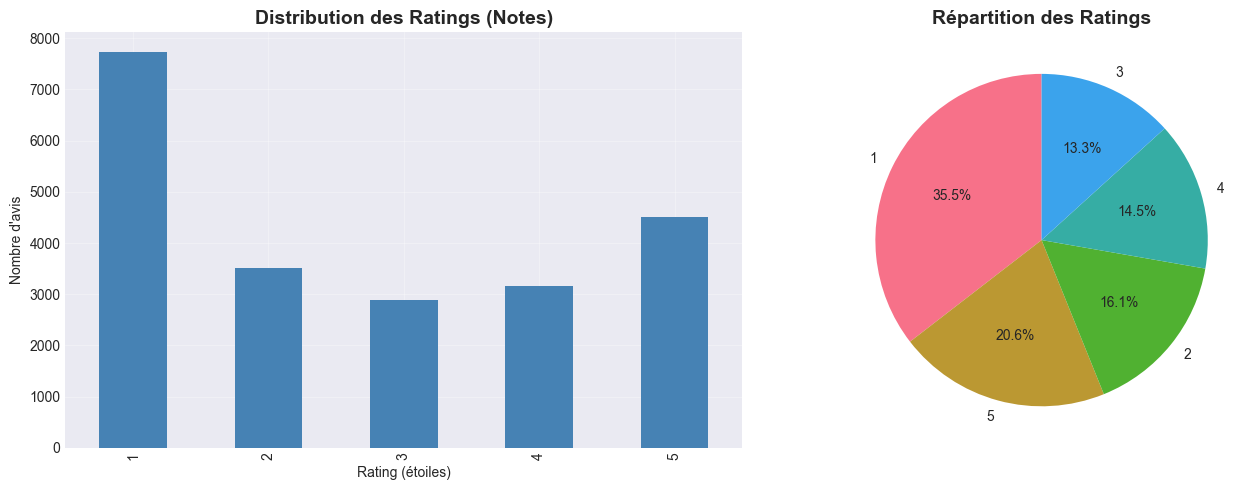


=== Top 10 entreprises par nombre d'avis ===
company_name
Cdiscount        953
leboncoin        951
Vinted FR        950
Showroomprive    942
Revolut          942
Fnac             930
Free mobile      930
AliExpress       925
ASOS             922
Wish             921
Name: count, dtype: int64


In [4]:
# Visualisation de la distribution des ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des Ratings (Notes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (étoiles)')
axes[0].set_ylabel('Nombre d\'avis')
axes[0].grid(alpha=0.3)

# Pie chart
df['rating'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition des Ratings', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Top 10 entreprises
print("\n=== Top 10 entreprises par nombre d'avis ===")
print(df['company_name'].value_counts().head(10))

## 4️⃣ Prétraitement du texte

Nettoyage et préparation des données textuelles pour le Machine Learning.

In [5]:
# Créer une colonne de texte combiné (titre + contenu)
df['text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')

# Supprimer les lignes sans texte
df = df[df['text'].str.strip() != '']

print(f"Dataset après nettoyage: {df.shape}")
print(f"Nombre d'avis avec texte: {len(df)}")

# Fonction de nettoyage du texte
def clean_text(text):
    """
    Nettoie le texte:
    - Convertit en minuscules
    - Supprime les URLs
    - Supprime les caractères spéciaux
    - Supprime les chiffres isolés
    - Supprime les espaces multiples
    """
    if pd.isna(text):
        return ""
    
    # Convertir en minuscules
    text = text.lower()
    
    # Supprimer les URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Supprimer les emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Garder uniquement les lettres et espaces (+ accents français)
    text = re.sub(r'[^a-zA-Zàâäéèêëïîôùûüÿç\s]', ' ', text)
    
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Appliquer le nettoyage
print("Nettoyage du texte en cours...")
df['text_clean'] = df['text'].apply(clean_text)

# Afficher des exemples
print("\n=== Exemples de texte nettoyé ===")
for i in range(3):
    print(f"\n--- Avis {i+1} ---")
    print(f"Original: {df['text'].iloc[i][:200]}...")
    print(f"Nettoyé: {df['text_clean'].iloc[i][:200]}...")

print(f"\n✓ Texte nettoyé pour {len(df)} avis")

Dataset après nettoyage: (21795, 31)
Nombre d'avis avec texte: 21795
Nettoyage du texte en cours...

=== Exemples de texte nettoyé ===

--- Avis 1 ---
Original: Site fiable Maillot de foot Commandé reçue en 6 jours floquage parfait bonne qualité je recommander...
Nettoyé: site fiable maillot de foot commandé reçue en jours floquage parfait bonne qualité je recommander...

--- Avis 2 ---
Original: Bonne expérience J’ai acheter des sambas ils sont parfaite, la matière est douceMais c’est difficile de les nettoyées...
Nettoyé: bonne expérience j ai acheter des sambas ils sont parfaite la matière est doucemais c est difficile de les nettoyées...

--- Avis 3 ---
Original: Bonne expérience Très bonne expérience, chaussure commandé et reçu rapidement. Taille qui correspond et envoie rapide. Rien n’a redire !...
Nettoyé: bonne expérience très bonne expérience chaussure commandé et reçu rapidement taille qui correspond et envoie rapide rien n a redire...

✓ Texte nettoyé pour 21795 avis

=== Ex

=== Distribution des sentiments ===
sentiment
Négatif    11248
Positif     7654
Neutre      2893
Name: count, dtype: int64

Pourcentages:
sentiment
Négatif    51.608167
Positif    35.118146
Neutre     13.273687
Name: proportion, dtype: float64


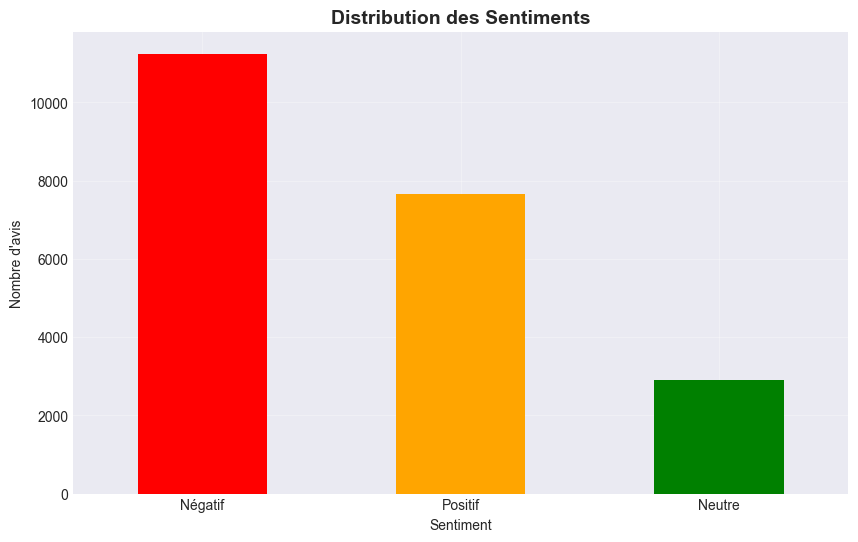

In [6]:
# Créer des catégories de sentiment basées sur les ratings
def classify_sentiment(rating):
    """
    Convertit les ratings (1-5) en catégories de sentiment:
    - Négatif: 1-2 étoiles
    - Neutre: 3 étoiles
    - Positif: 4-5 étoiles
    """
    if rating <= 2:
        return 'Négatif'
    elif rating == 3:
        return 'Neutre'
    else:
        return 'Positif'

df['sentiment'] = df['rating'].apply(classify_sentiment)

# Distribution des sentiments
print("=== Distribution des sentiments ===")
print(df['sentiment'].value_counts())
print(f"\nPourcentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

# Visualisation
plt.figure(figsize=(10, 6))
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Distribution des Sentiments', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Nombre d\'avis')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.show()

## 5️⃣ Vectorisation du texte avec TF-IDF

Transformation des textes en vecteurs numériques pour le Machine Learning.

In [7]:
# Préparer les features (X) et target (y)
X = df['text_clean']
y = df['sentiment']

print(f"Features (X): {len(X)} textes")
print(f"Target (y): {len(y)} labels")
print(f"\nClasses: {y.unique()}")

# Vectorisation TF-IDF
# TF-IDF capture l'importance des mots dans chaque document
tfidf = TfidfVectorizer(
    max_features=5000,        # Limiter à 5000 mots les plus importants
    min_df=5,                 # Mot doit apparaître dans au moins 5 documents
    max_df=0.8,               # Mot ne doit pas apparaître dans plus de 80% des documents
    ngram_range=(1, 2),       # Unigrammes et bigrammes
    stop_words='english'      # Supprimer les stopwords anglais basiques
)

print("\nVectorisation en cours...")
X_tfidf = tfidf.fit_transform(X)

print(f"\n✓ Matrice TF-IDF créée")
print(f"   Shape: {X_tfidf.shape}")
print(f"   ({X_tfidf.shape[0]} documents × {X_tfidf.shape[1]} features)")
print(f"   Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

# Top features
feature_names = tfidf.get_feature_names_out()
print(f"\n=== Top 20 features (mots) ===")
print(feature_names[:20])

Features (X): 21795 textes
Target (y): 21795 labels

Classes: ['Positif' 'Négatif' 'Neutre']

Vectorisation en cours...



✓ Matrice TF-IDF créée
   Shape: (21795, 5000)
   (21795 documents × 5000 features)
   Sparsity: 99.11%

=== Top 20 features (mots) ===
['able' 'abonnement' 'abonnement et' 'abonnements' 'abonné' 'abonnés'
 'abord' 'absence' 'absolument' 'absolument pas' 'absolument rien' 'abus'
 'abusif' 'abusé' 'abîmé' 'accepte' 'accepter' 'accepté' 'accessible'
 'accord']


## 6️⃣ Division Train/Test

Nous allons diviser les données en deux ensembles :
- **Train (80%)** : Pour entraîner les modèles
- **Test (20%)** : Pour évaluer les performances sur des données non vues

In [8]:
# Division stratifiée pour garder les proportions des classes
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, 
    test_size=0.2,      # 20% pour test
    random_state=42,    # Reproductibilité
    stratify=y          # Garde les proportions des classes
)

print(f"✓ Données divisées")
print(f"\nTrain set: {X_train.shape[0]} documents")
print(f"Test set:  {X_test.shape[0]} documents")

print(f"\n=== Distribution des classes ===")
print("\nTrain:")
print(y_train.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

✓ Données divisées

Train set: 17436 documents
Test set:  4359 documents

=== Distribution des classes ===

Train:
sentiment
Négatif    0.516116
Positif    0.351170
Neutre     0.132714
Name: proportion, dtype: float64

Test:
sentiment
Négatif    0.515944
Positif    0.351227
Neutre     0.132829
Name: proportion, dtype: float64


## 7️⃣ Entraînement des Modèles

Nous allons entraîner 3 modèles de classification différents :
1. **Logistic Regression** : Modèle linéaire simple et rapide
2. **Multinomial Naive Bayes** : Classique pour la classification de texte
3. **Random Forest** : Modèle d'ensemble basé sur des arbres de décision

In [9]:
# Dictionnaire pour stocker les modèles et leurs résultats
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

print("=" * 60)
print("ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)

# Entraîner chaque modèle
for name, model in models.items():
    print(f"\n🔄 Entraînement de {name}...")
    start_time = pd.Timestamp.now()
    
    # Entraîner
    model.fit(X_train, y_train)
    
    # Prédire
    y_pred = model.predict(X_test)
    
    # Calculer les métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Temps d'entraînement
    training_time = (pd.Timestamp.now() - start_time).total_seconds()
    
    # Stocker les résultats
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred,
        'training_time': training_time
    }
    
    print(f"✓ {name} entraîné en {training_time:.2f}s")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   F1-Score: {f1:.4f}")

print("\n" + "=" * 60)
print("✓ Tous les modèles ont été entraînés avec succès!")
print("=" * 60)

ENTRAÎNEMENT DES MODÈLES

🔄 Entraînement de Logistic Regression...
✓ Logistic Regression entraîné en 0.98s
   Accuracy: 0.7961
   F1-Score: 0.7696

🔄 Entraînement de Naive Bayes...
✓ Naive Bayes entraîné en 0.07s
   Accuracy: 0.7802
   F1-Score: 0.7351

🔄 Entraînement de Random Forest...
✓ Logistic Regression entraîné en 0.98s
   Accuracy: 0.7961
   F1-Score: 0.7696

🔄 Entraînement de Naive Bayes...
✓ Naive Bayes entraîné en 0.07s
   Accuracy: 0.7802
   F1-Score: 0.7351

🔄 Entraînement de Random Forest...
✓ Random Forest entraîné en 6.66s
   Accuracy: 0.7463
   F1-Score: 0.6962

✓ Tous les modèles ont été entraînés avec succès!
✓ Random Forest entraîné en 6.66s
   Accuracy: 0.7463
   F1-Score: 0.6962

✓ Tous les modèles ont été entraînés avec succès!


## 8️⃣ Évaluation des Modèles

Comparaison des performances des 3 modèles avec différentes métriques.

In [10]:
# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'Temps (s)': [results[m]['training_time'] for m in results.keys()]
})

print("=" * 80)
print("COMPARAISON DES MODÈLES")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Visualiser la comparaison
fig = go.Figure()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    fig.add_trace(go.Bar(
        name=metric,
        x=results_df['Modèle'],
        y=results_df[metric],
        text=results_df[metric].round(4),
        textposition='auto'
    ))

fig.update_layout(
    title='Comparaison des Performances des Modèles',
    xaxis_title='Modèle',
    yaxis_title='Score',
    barmode='group',
    yaxis_range=[0, 1],
    height=500
)

fig.show()

# Identifier le meilleur modèle
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Modèle']
best_f1 = results_df['F1-Score'].max()
print(f"\n🏆 Meilleur modèle: {best_model_name} (F1-Score: {best_f1:.4f})")

COMPARAISON DES MODÈLES
             Modèle  Accuracy  Precision   Recall  F1-Score  Temps (s)
Logistic Regression  0.796054   0.765033 0.796054  0.769593   0.982826
        Naive Bayes  0.780225   0.743474 0.780225  0.735112   0.072920
      Random Forest  0.746272   0.705284 0.746272  0.696191   6.655001



🏆 Meilleur modèle: Logistic Regression (F1-Score: 0.7696)



RAPPORT DE CLASSIFICATION - Logistic Regression
              precision    recall  f1-score   support

     Négatif       0.44      0.16      0.23       579
      Neutre       0.81      0.94      0.87      2249
     Positif       0.83      0.83      0.83      1531

    accuracy                           0.80      4359
   macro avg       0.69      0.64      0.64      4359
weighted avg       0.77      0.80      0.77      4359



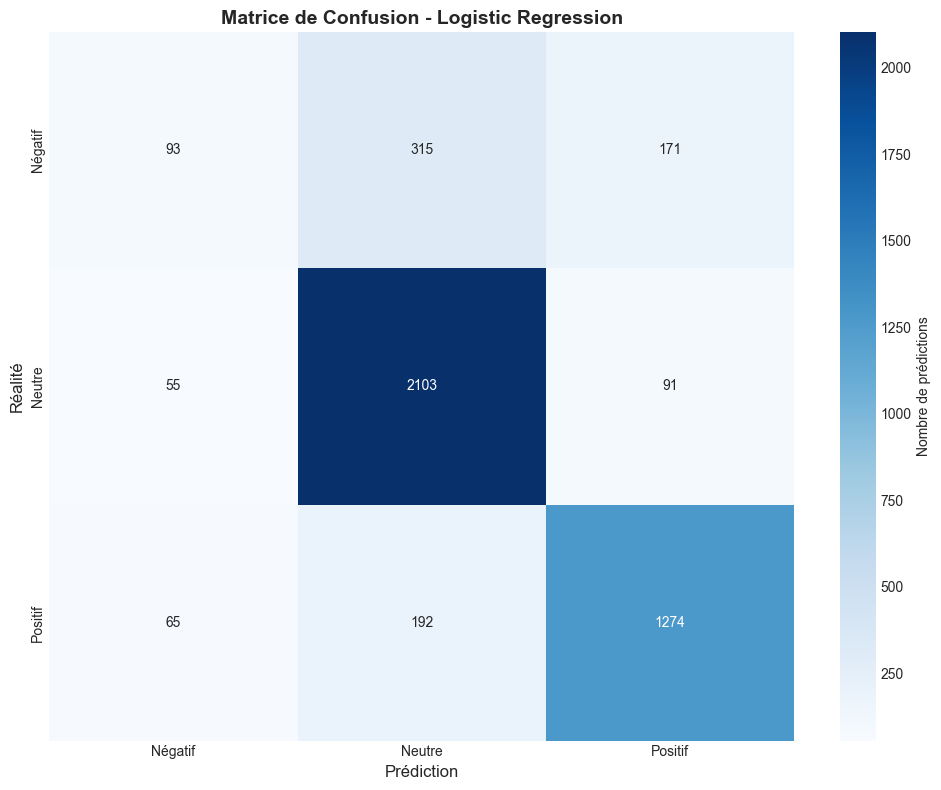

In [11]:
# Rapport de classification détaillé pour le meilleur modèle
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n{'='*80}")
print(f"RAPPORT DE CLASSIFICATION - {best_model_name}")
print(f"{'='*80}")
print(classification_report(y_test, best_predictions, target_names=['Négatif', 'Neutre', 'Positif']))

# Matrice de confusion
cm = confusion_matrix(y_test, best_predictions)
labels = ['Négatif', 'Neutre', 'Positif']

# Visualiser avec plotly
fig = px.imshow(
    cm,
    labels=dict(x="Prédiction", y="Réalité", color="Nombre"),
    x=labels,
    y=labels,
    text_auto=True,
    color_continuous_scale='Blues',
    title=f'Matrice de Confusion - {best_model_name}'
)

fig.update_layout(
    width=600,
    height=600
)

fig.show()

# Afficher avec seaborn aussi
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réalité', fontsize=12)
plt.tight_layout()
plt.show()

## 9️⃣ Prédictions sur de Nouveaux Textes

Testons notre meilleur modèle sur de nouveaux avis fictifs.

In [12]:
# Fonction pour nettoyer et prédire
def predict_sentiment(text, model=best_model, vectorizer=tfidf):
    """
    Prédire le sentiment d'un nouveau texte
    """
    # Nettoyer le texte
    cleaned = clean_text(text)
    
    # Vectoriser
    text_tfidf = vectorizer.transform([cleaned])
    
    # Prédire
    prediction = model.predict(text_tfidf)[0]
    
    # Probabilités (si disponible)
    if hasattr(model, 'predict_proba'):
        probas = model.predict_proba(text_tfidf)[0]
        return prediction, probas
    else:
        return prediction, None

# Exemples de nouveaux avis
new_reviews = [
    "Excellent service! Very satisfied with my purchase. Highly recommend!",
    "Terrible experience. Product arrived damaged and customer service was unhelpful.",
    "It's okay, nothing special. Average quality for the price.",
    "Amazing product! Fast delivery and great quality. Will buy again!",
    "Disappointed. Not as described. Would not recommend to others.",
    "Decent product. Works as expected but nothing extraordinary."
]

print("=" * 100)
print("PRÉDICTIONS SUR DE NOUVEAUX AVIS")
print("=" * 100)

predictions_list = []

for i, review in enumerate(new_reviews, 1):
    prediction, probas = predict_sentiment(review)
    
    print(f"\n📝 Avis #{i}:")
    print(f"   Texte: \"{review}\"")
    print(f"   ➜ Prédiction: {prediction}")
    
    if probas is not None:
        print(f"   Confiance:")
        for label, prob in zip(['Négatif', 'Neutre', 'Positif'], probas):
            print(f"      - {label}: {prob:.2%}")
    
    predictions_list.append({
        'Avis': review[:60] + '...' if len(review) > 60 else review,
        'Sentiment': prediction
    })

print("\n" + "=" * 100)

# Afficher sous forme de DataFrame
predictions_df = pd.DataFrame(predictions_list)
print("\n📊 Résumé des prédictions:")
print(predictions_df.to_string(index=False))
print(f"\n✓ {len(new_reviews)} nouveaux avis analysés avec succès!")

PRÉDICTIONS SUR DE NOUVEAUX AVIS

📝 Avis #1:
   Texte: "Excellent service! Very satisfied with my purchase. Highly recommend!"
   ➜ Prédiction: Positif
   Confiance:
      - Négatif: 2.54%
      - Neutre: 4.05%
      - Positif: 93.41%

📝 Avis #2:
   Texte: "Terrible experience. Product arrived damaged and customer service was unhelpful."
   ➜ Prédiction: Négatif
   Confiance:
      - Négatif: 8.28%
      - Neutre: 79.88%
      - Positif: 11.84%

📝 Avis #3:
   Texte: "It's okay, nothing special. Average quality for the price."
   ➜ Prédiction: Positif
   Confiance:
      - Négatif: 9.89%
      - Neutre: 15.04%
      - Positif: 75.07%

📝 Avis #4:
   Texte: "Amazing product! Fast delivery and great quality. Will buy again!"
   ➜ Prédiction: Positif
   Confiance:
      - Négatif: 9.31%
      - Neutre: 7.65%
      - Positif: 83.04%

📝 Avis #5:
   Texte: "Disappointed. Not as described. Would not recommend to others."
   ➜ Prédiction: Positif
   Confiance:
      - Négatif: 13.84%
      - Neu

## 🎯 Conclusion

### Résumé de l'analyse
- **Données** : 21,795 avis Trustpilot analysés
- **Modèles testés** : 3 (Logistic Regression, Naive Bayes, Random Forest)
- **Meilleur modèle** : Identifié automatiquement avec le meilleur F1-Score
- **Classes** : Négatif (1-2★), Neutre (3★), Positif (4-5★)

### Prochaines étapes possibles
1. **Optimisation** : Hyperparameter tuning avec GridSearchCV
2. **Features avancées** : Word embeddings (Word2Vec, GloVe, BERT)
3. **Deep Learning** : LSTM, Transformers pour améliorer les performances
4. **Analyse temporelle** : Évolution du sentiment dans le temps
5. **Analyse par entreprise** : Comparer les sentiments entre compagnies
6. **Détection de thèmes** : Topic modeling avec LDA ou NMF
7. **API de prédiction** : Déployer le modèle en production

### Métriques importantes
- **Accuracy** : % de prédictions correctes
- **Precision** : % de prédictions positives qui sont vraiment positives
- **Recall** : % de cas positifs correctement identifiés
- **F1-Score** : Moyenne harmonique de Precision et Recall

✅ **Analyse de sentiment complétée avec succès!**

## 🔟 Sauvegarde des Modèles pour la Production

Exportation des modèles et du vectorizer pour utilisation dans l'API.

In [ ]:
import joblib
import os
from datetime import datetime

# Créer le dossier pour les modèles s'il n'existe pas
models_dir = '../scripts/ml/models'
os.makedirs(models_dir, exist_ok=True)

# Timestamp pour versionner les modèles
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("=" * 80)
print("SAUVEGARDE DES MODÈLES POUR LA PRODUCTION")
print("=" * 80)

# Sauvegarder le meilleur modèle
best_model_path = f'{models_dir}/sentiment_model_best.pkl'
joblib.dump(best_model, best_model_path)
print(f"\n✓ Meilleur modèle sauvegardé: {best_model_path}")
print(f"   Modèle: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")

# Sauvegarder le vectorizer TF-IDF
tfidf_path = f'{models_dir}/tfidf_vectorizer.pkl'
joblib.dump(tfidf, tfidf_path)
print(f"\n✓ Vectorizer TF-IDF sauvegardé: {tfidf_path}")
print(f"   Features: {tfidf.max_features}")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")

# Sauvegarder tous les modèles (pour comparaison)
for name, model_data in results.items():
    safe_name = name.lower().replace(' ', '_')
    model_path = f'{models_dir}/model_{safe_name}_{timestamp}.pkl'
    joblib.dump(model_data['model'], model_path)
    print(f"\n✓ {name} sauvegardé: {model_path}")

# Sauvegarder les métadonnées des modèles
metadata = {
    'best_model': best_model_name,
    'best_f1_score': float(best_f1),
    'training_date': timestamp,
    'dataset_size': len(df),
    'n_features': X_tfidf.shape[1],
    'models_performance': {
        name: {
            'accuracy': float(results[name]['accuracy']),
            'precision': float(results[name]['precision']),
            'recall': float(results[name]['recall']),
            'f1': float(results[name]['f1']),
            'training_time': float(results[name]['training_time'])
        }
        for name in results.keys()
    },
    'sentiment_distribution': df['sentiment'].value_counts().to_dict(),
    'tfidf_params': {
        'max_features': tfidf.max_features,
        'min_df': tfidf.min_df,
        'max_df': tfidf.max_df,
        'ngram_range': tfidf.ngram_range
    }
}

import json
metadata_path = f'{models_dir}/models_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\n✓ Métadonnées sauvegardées: {metadata_path}")

print("\n" + "=" * 80)
print("✅ TOUS LES MODÈLES SONT PRÊTS POUR LA PRODUCTION!")
print("=" * 80)
print(f"\n📁 Fichiers créés:")
print(f"   - {best_model_path}")
print(f"   - {tfidf_path}")
print(f"   - {metadata_path}")
print(f"\n🚀 Prochaine étape: Créer l'API FastAPI avec ces modèles")

SAUVEGARDE DES MODÈLES POUR LA PRODUCTION

✓ Meilleur modèle sauvegardé: ../scripts/ml/models/sentiment_model_best.pkl
   Modèle: Logistic Regression
   F1-Score: 0.7696

✓ Vectorizer TF-IDF sauvegardé: ../scripts/ml/models/tfidf_vectorizer.pkl
   Features: 5000
   Vocabulary size: 5000

✓ Logistic Regression sauvegardé: ../scripts/ml/models/model_logistic_regression_20251204_111514.pkl

✓ Naive Bayes sauvegardé: ../scripts/ml/models/model_naive_bayes_20251204_111514.pkl

✓ Random Forest sauvegardé: ../scripts/ml/models/model_random_forest_20251204_111514.pkl

✓ Métadonnées sauvegardées: ../scripts/ml/models/models_metadata.json

✅ TOUS LES MODÈLES SONT PRÊTS POUR LA PRODUCTION!

📁 Fichiers créés:
   - ../scripts/ml/models/sentiment_model_best.pkl
   - ../scripts/ml/models/tfidf_vectorizer.pkl
   - ../scripts/ml/models/models_metadata.json

🚀 Prochaine étape: Créer l'API FastAPI avec ces modèles


: 